In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 992kB/s]

In [3]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [5]:
data_df = pd.read_csv("./rice-type-classification/riceClassification.csv")
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [6]:
data_df.dropna(inplace = True)
data_df.drop(['id'],axis = 1, inplace = True)
print(data_df.shape)
data_df.head()


(18185, 11)


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [7]:
print(data_df['Class'].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [8]:
original_df = data_df.copy()
for column in data_df.columns:
  data_df[column] = data_df[column]/data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [9]:
x = np.array(data_df.iloc[:,:-1])
y = np.array(data_df.iloc[:,-1])

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3)
x_test, x_val, y_test, y_val = train_test_split(x_test,y_test,test_size=0.5)
print(x_train.shape)
print(x_test.shape)
print(x_val.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [11]:
class dataset(Dataset):
  def __init__(self,x,y):
    self.x = torch.tensor(x,dtype=torch.float32).to(device)
    self.y = torch.tensor(y,dtype=torch.float32).to(device)

  def __len__(self):
    return len(self.x)

  def __getitem__(self,idx):
    return self.x[idx],self.y[idx]

In [12]:
training_data = dataset(x_train,y_train)
validation_data = dataset(x_val,y_val)
testing_data = dataset(x_test,y_test)

In [13]:
train_dataloader=DataLoader(training_data,batch_size=32,shuffle=True)
validation_dataloader=DataLoader(validation_data,batch_size=32,shuffle=True)
testing_dataloader=DataLoader(testing_data,batch_size=32,shuffle=True)

In [14]:
class mymodel(nn.Module):
    def __init__(self):
        super(mymodel, self).__init__()

        self.input_layer = nn.Linear(x.shape[1],10)
        self.linear = nn.Linear(10,1)
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

    def forward(self, x):
      x=self.input_layer(x)

      x=self.linear(x)
      x=self.sigmoid(x)

      return x

model = mymodel().to(device)

In [15]:
summary(model,(x.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [16]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=1e-3)

In [19]:
total_loss_train_plot=[]
total_loss_validation_plot=[]
total_acc_train_plot=[]
total_acc_validation_plot=[]

epoches = 10
for epoch in range(epoches):
  total_acc_train=0
  total_acc_val=0
  total_loss_train=0
  total_loss_val=0

  for data in train_dataloader:
    inputs,labels = data
    prediction=model(inputs).squeeze(1)

    batch_loss=criterion(prediction,labels)

    total_loss_train+=batch_loss.item()
    correct=(prediction.round()==labels).sum().item()
    total_acc_train+=correct

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in validation_dataloader:
      inputs,labels = data
      prediction=model(inputs).squeeze(1)
      batch_loss=criterion(prediction,labels)

      total_loss_val+=batch_loss.item()
      correct=(prediction.round()==labels).sum().item()
      total_acc_val+=correct

  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_loss_validation_plot.append(round(total_loss_val/1000,4))

  total_acc_train_plot.append(round(total_acc_train/training_data.__len__()*100,4))
  total_acc_validation_plot.append(round(total_acc_val/validation_data.__len__()*100,4))

  print(f'''Epoch {epoch+1}/{epoches} Train Loss:{round(total_loss_train/1000,4)}
  Train accuracy:{round(total_acc_train/training_data.__len__()*100,4)}
   Val Loss:{round(total_loss_val/1000,4)}
  Val accuracy:{round(total_acc_val/validation_data.__len__()*100,4)}''')
  print("==========")

Epoch 1/10 Train Loss:0.0166
  Train accuracy:98.6723
   Val Loss:0.0031
  Val accuracy:98.7903
Epoch 2/10 Train Loss:0.0166
  Train accuracy:98.5938
   Val Loss:0.0032
  Val accuracy:98.717
Epoch 3/10 Train Loss:0.0166
  Train accuracy:98.5702
   Val Loss:0.0031
  Val accuracy:98.7903
Epoch 4/10 Train Loss:0.0166
  Train accuracy:98.5623
   Val Loss:0.0033
  Val accuracy:98.827
Epoch 5/10 Train Loss:0.0167
  Train accuracy:98.6016
   Val Loss:0.0031
  Val accuracy:98.7537
Epoch 6/10 Train Loss:0.0164
  Train accuracy:98.6095
   Val Loss:0.0033
  Val accuracy:98.827
Epoch 7/10 Train Loss:0.0168
  Train accuracy:98.6095
   Val Loss:0.0032
  Val accuracy:98.827
Epoch 8/10 Train Loss:0.0167
  Train accuracy:98.5781
   Val Loss:0.0031
  Val accuracy:98.717
Epoch 9/10 Train Loss:0.0165
  Train accuracy:98.5781
   Val Loss:0.0031
  Val accuracy:98.717
Epoch 10/10 Train Loss:0.0165
  Train accuracy:98.5702
   Val Loss:0.0031
  Val accuracy:98.7537


In [21]:
with torch.no_grad():
  total_loss_test=0
  total_acc_test=0
  for data in testing_dataloader:
    inputs,labels = data
    
    prediction=model(inputs).squeeze(1)
    
    batch_loss_test=criterion(prediction,labels).item()
    total_loss_test+=batch_loss_test
    
    correct=(prediction.round()==labels).sum().item()
    total_acc_test+=correct
  print("Testing accuracy:",round(total_acc_test/testing_data.__len__()*100,4))

Testing accuracy: 98.6804


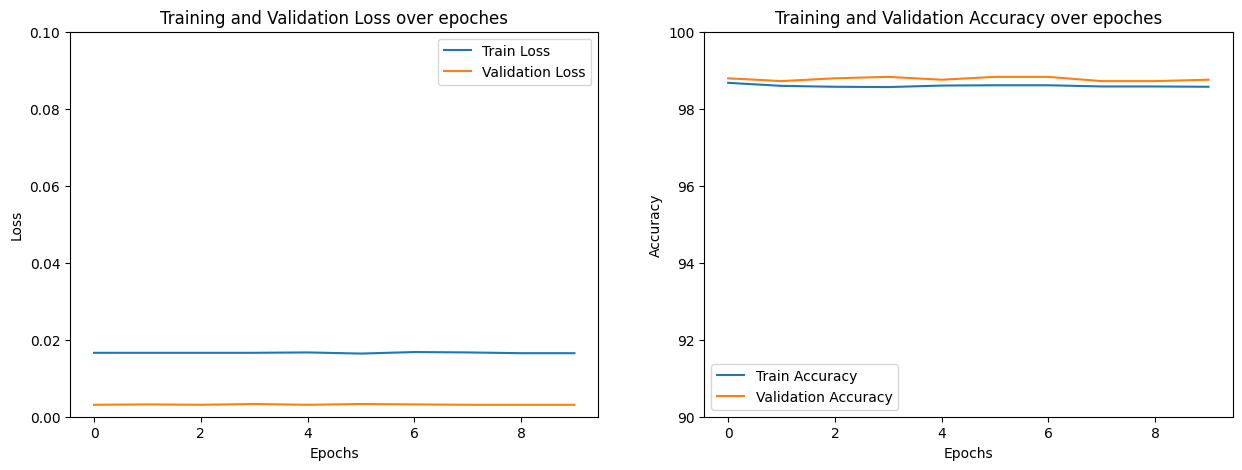

In [26]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

ax[0].plot(total_loss_train_plot,label='Train Loss')
ax[0].plot(total_loss_validation_plot,label='Validation Loss')
ax[0].set_title('Training and Validation Loss over epoches')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0,0.1])
ax[0].legend()

ax[1].plot(total_acc_train_plot,label='Train Accuracy')
ax[1].plot(total_acc_validation_plot,label='Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy over epoches')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim([90,100])
ax[1].legend()

plt.show()

In [29]:
Area=3289/original_df['Area'].abs().max()
MajorAxisLength=81/original_df['MajorAxisLength'].abs().max()
MinorAxisLength=42/original_df['MinorAxisLength'].abs().max()
Eccentricity=32/original_df['Eccentricity'].abs().max()
ConvexArea=12/original_df['ConvexArea'].abs().max()
EquivDiameter=33/original_df['EquivDiameter'].abs().max()
Extent=98/original_df['Extent'].abs().max()
Perimeter=927/original_df['Perimeter'].abs().max()
Roundness=677/original_df['Roundness'].abs().max()
AspectRation=24/original_df['AspectRation'].abs().max()
my_prediction=model(torch.tensor([Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation],dtype=torch.float32).to(device))

In [31]:
my_prediction

tensor([0.], device='cuda:0', grad_fn=<SigmoidBackward0>)